# Unified C. elegans sensory–motor information + prediction pipeline

This notebook merges the *key functional features* into a single, coherent workflow:

- broad discovery (archive extraction - redacted utility)
- BrainScanner + exported_data loaders
- sensory/motor/interneuron toggles
- lag-optimized correlation + cross-correlation plots
- mutual information (continuous + binned) and MI vs bins
- transfer entropy (discrete plug-in)
- Gaussian predictive information (linear TE analogue)
- surrogate nulls + BH-FDR for delayed-correlation screen
- trajectory prediction with weighted contributor percentages (grouped permutation importance)
- multi-dataset training across [0... 112] and evaluation on a held-out dataset

Outputs are designed to: quantify sensory --> motor predictive structure in the worm, and connect it to the broader '10 bits/s' bottleneck framing.

## 0) Import + path bootstrap

In [69]:

from pathlib import Path
import sys

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import celegans_unified_pipeline as cup


## 1) Discovery + optional third-party package status

In [70]:

from pprint import pprint
from celegans_unified_pipeline.third_party import prepare_pipeline_environment
from celegans_unified_pipeline.discover import choose_best_exported_dir, choose_brainscanner_dir

EXTRA_ROOTS = [str(Path.cwd())]
UNPACK_ARCHIVES = False
INCLUDE_HOME = True
MAX_DEPTH = 10

ATTEMPT_LOCAL_PIP_INSTALL = False
EDITABLE_INSTALL = False

discovery, repo_statuses = prepare_pipeline_environment(
    extra_roots=EXTRA_ROOTS,
    unpack_archives=UNPACK_ARCHIVES,
    include_home=INCLUDE_HOME,
    max_depth=MAX_DEPTH,
    attempt_local_pip_install=ATTEMPT_LOCAL_PIP_INSTALL,
    editable_install=EDITABLE_INSTALL,
)

pprint(discovery.summary())
print("\nRepo import status:")
for k,v in repo_statuses.items():
    print(k, "imported=", v.imported, "message=", v.message)

print("\nBest exported_data:", choose_best_exported_dir(discovery))
print("Example BrainScanner:", choose_brainscanner_dir(discovery))


{'atlas_pickle_files': ['C:\\Users\\axfjr\\Documents\\GitHub\\Baby-Copy\\python\\baby\\models\\ct_rf_20210125_9.pkl',
                        'C:\\Users\\axfjr\\Documents\\GitHub\\Baby-Copy\\python\\baby\\models\\ct_rf_20210201_12.pkl',
                        'C:\\Users\\axfjr\\Documents\\GitHub\\Baby-Copy\\python\\baby\\models\\ct_rf_20210201_4.pkl',
                        'C:\\Users\\axfjr\\Documents\\GitHub\\Baby-Copy\\python\\baby\\models\\mb_model_20201022.pkl',
                        'C:\\Users\\axfjr\\Documents\\GitHub\\Baby-Copy\\python\\baby\\models\\mb_model_60x_1z_evolve_210302.pkl',
                        'C:\\Users\\axfjr\\Documents\\GitHub\\Baby-Copy\\python\\baby\\models\\mb_model_60x_1z_prime_210302.pkl',
                        'C:\\Users\\axfjr\\Documents\\GitHub\\Baby-Copy\\python\\baby\\models\\mb_model_60x_3z_evolve_20210215.pkl',
                        'C:\\Users\\axfjr\\Documents\\GitHub\\Baby-Copy\\python\\baby\\models\\mb_model_60x_3z_prime_20210215.pkl',


## 2) Load neuron classes + choose dataset

In [71]:

from celegans_unified_pipeline.loaders import parse_neuron_class_file, load_exported_experiment, load_brainscanner_dataset, list_exported_ids
from celegans_unified_pipeline.discover import choose_best_exported_dir, choose_brainscanner_dir

DATASET_SOURCE = "exported_data"   # or "brainscanner"
EXPORTED_EXP_ID = 97
PREFERRED_BRAINSCANNER = None
SIGNAL_KEY = "a"

if not discovery.neuron_class_files:
    raise FileNotFoundError("No neuron_class.rtf found. Add its folder to EXTRA_ROOTS or set UNPACK_ARCHIVES=True.")
neuron_classes = parse_neuron_class_file(discovery.neuron_class_files[0])
print("n sensory classes:", len(neuron_classes["sensory"]))
print("n motor classes:", len(neuron_classes["motor"]))
atlas_path = discovery.atlas_tsv_files[0] if discovery.atlas_tsv_files else None

if DATASET_SOURCE == "brainscanner":
    ds_dir = choose_brainscanner_dir(discovery, preferred=PREFERRED_BRAINSCANNER)
    dataset = load_brainscanner_dataset(ds_dir, signal_key=SIGNAL_KEY)
else:
    ex_dir = choose_best_exported_dir(discovery)
    dataset = load_exported_experiment(ex_dir, EXPORTED_EXP_ID)

print(dataset.name, dataset.source_type, dataset.signals.shape, "sample_rate=", dataset.sample_rate)
print("atlas_path:", atlas_path)


n sensory classes: 20
n motor classes: 16
exported_97 exported_data (2922, 109) sample_rate= 2.0
atlas_path: None


### Label Verification

In [72]:
labels = list(dataset.label_to_index().keys())

sens = set(neuron_classes["sensory"])
motor = set(neuron_classes["motor"])

matched_sens = sorted([x for x in labels if x in sens])
matched_motor = sorted([x for x in labels if x in motor])

print("Dataset total labels:", len(labels))
print("Matched sensory:", len(matched_sens), matched_sens)
print("Matched motor:", len(matched_motor), matched_motor)

Dataset total labels: 63
Matched sensory: 9 ['AWBR', 'CEPDR', 'IL1VL', 'IL1VR', 'OLQDL', 'OLQDR', 'URXL', 'URYVL', 'URYVR']
Matched motor: 6 ['RMDDL', 'RMDDR', 'RMDL', 'RMDVL', 'RMEL', 'SMDVR']


## 3) Single-dataset end-to-end run (screen → contributors → prediction)

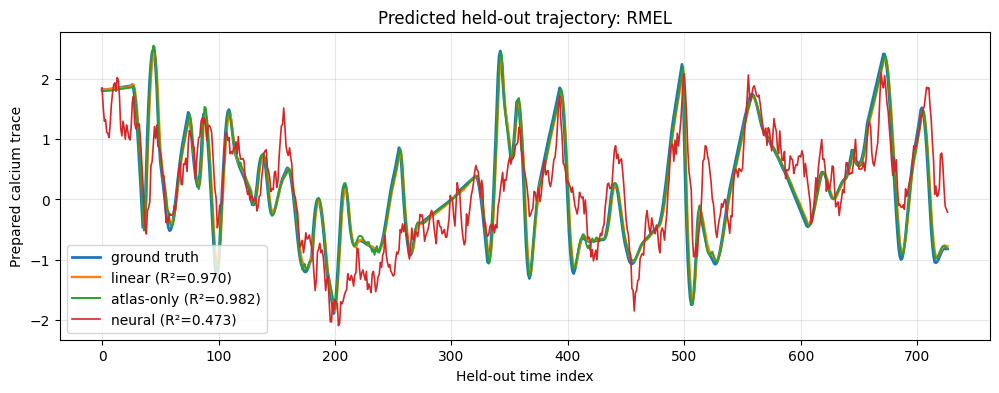

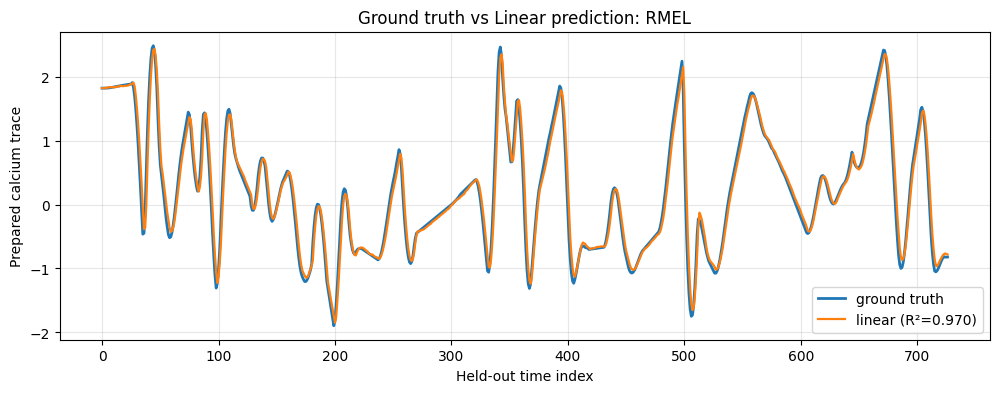

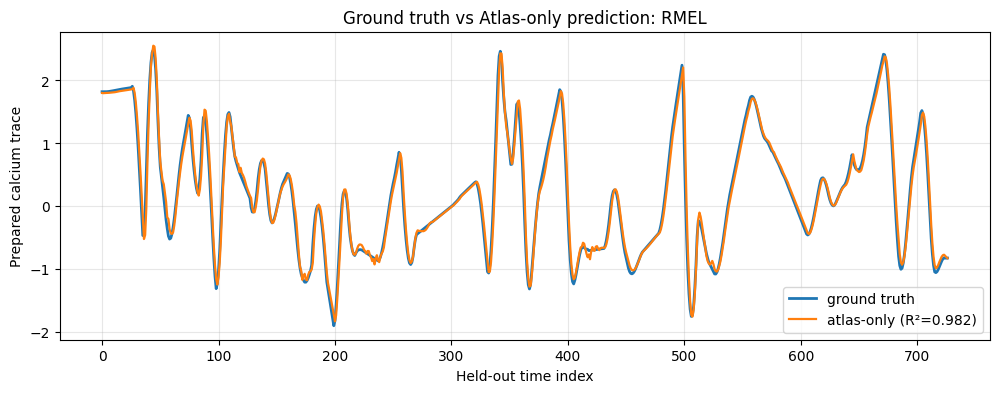

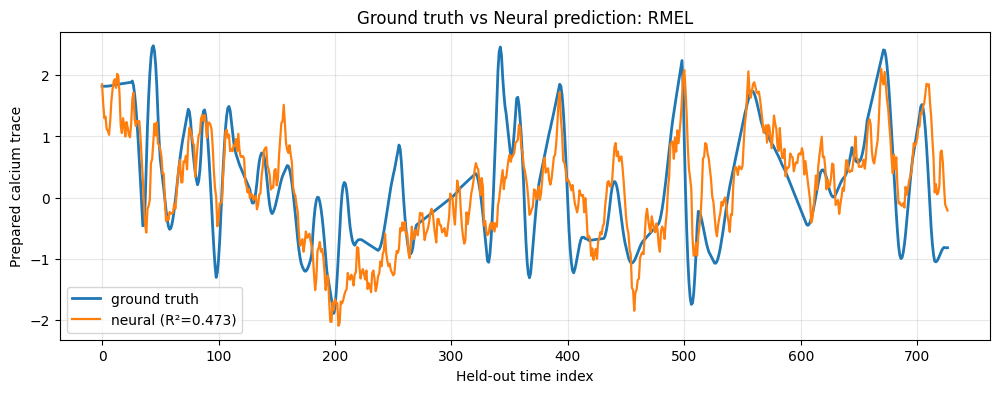

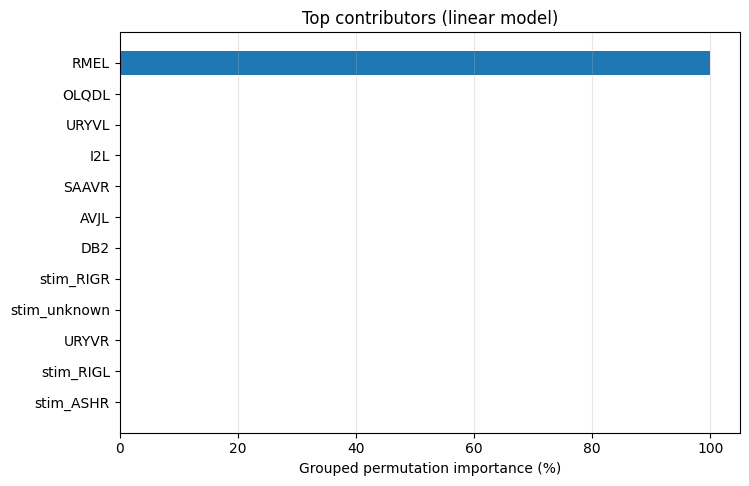

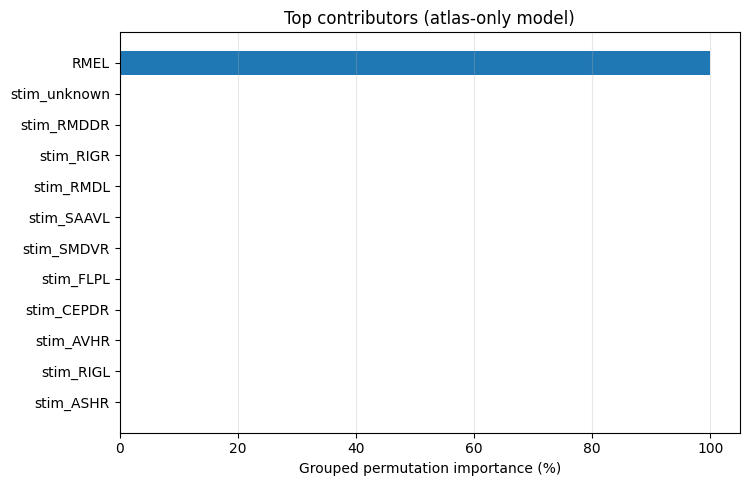

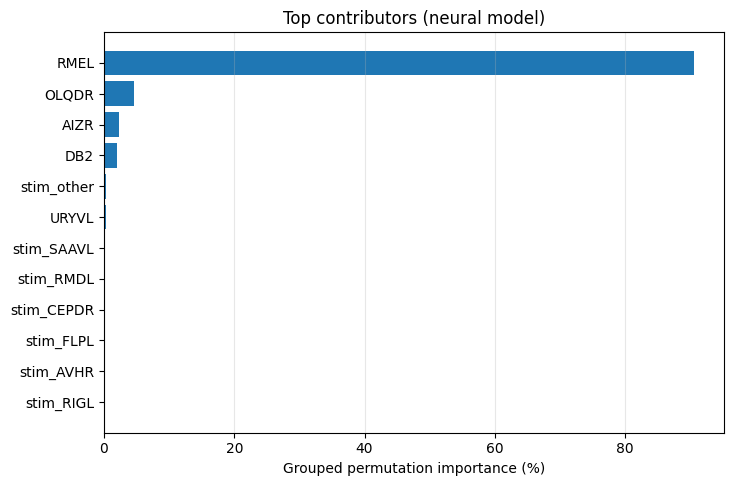

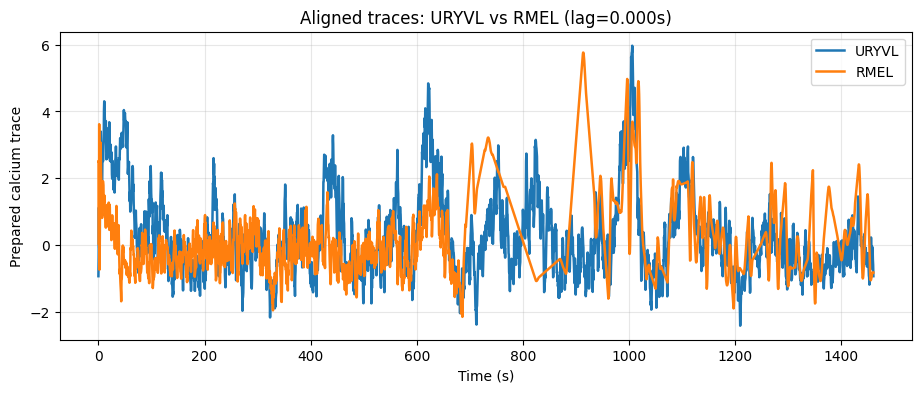

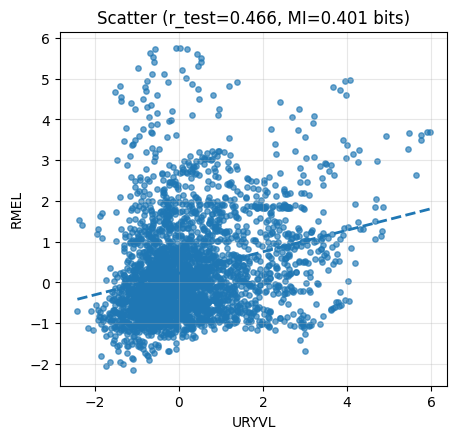

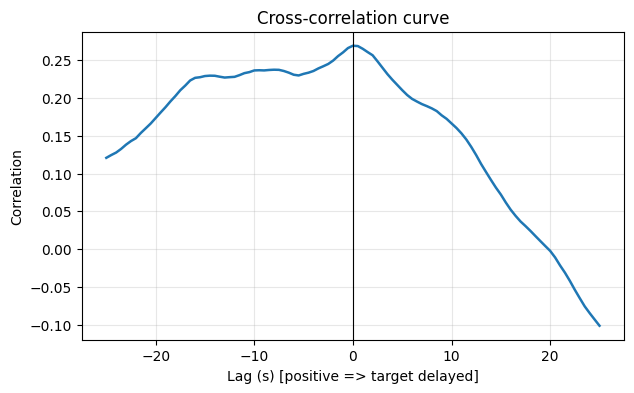

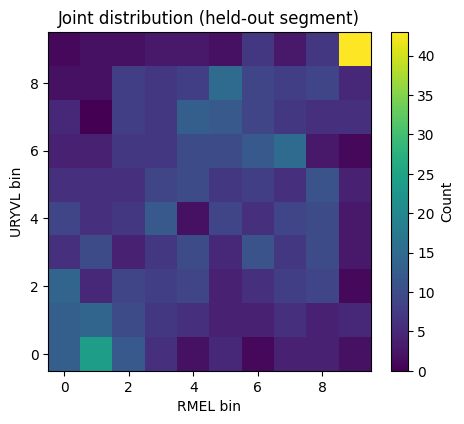

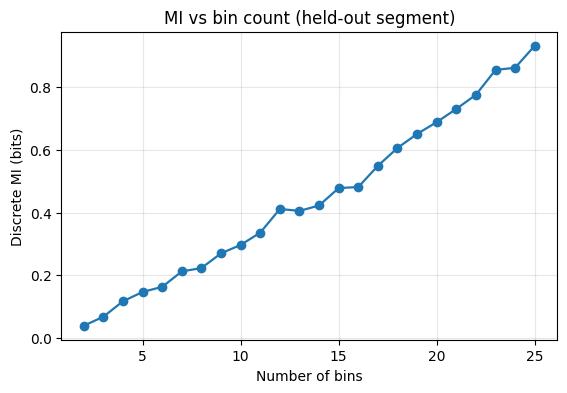

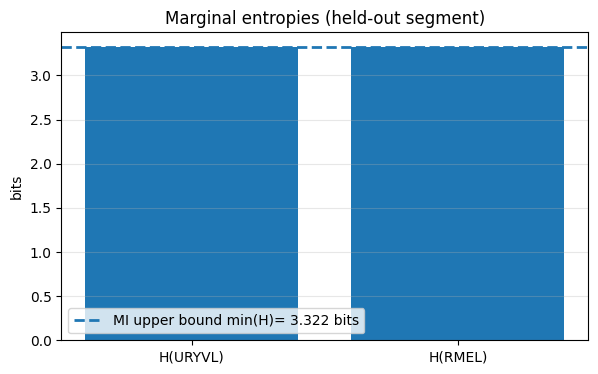

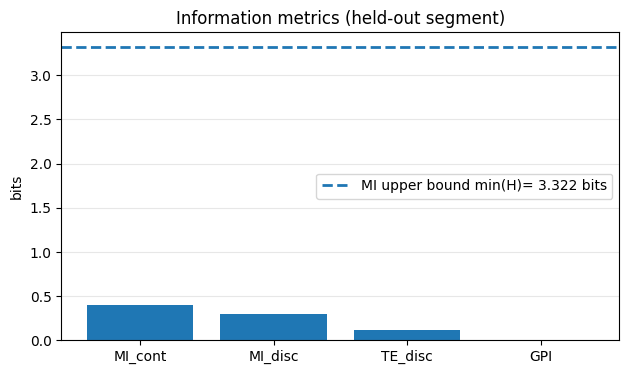

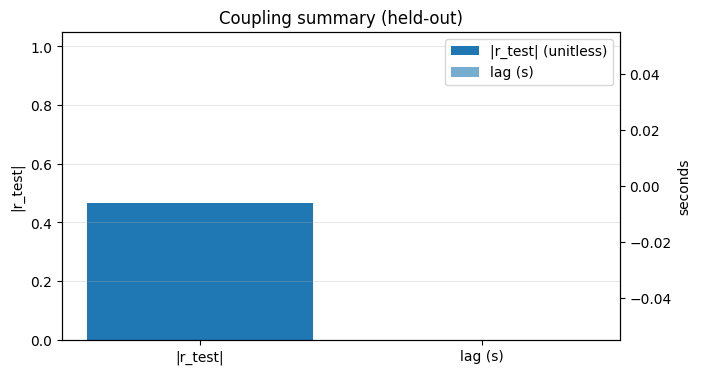

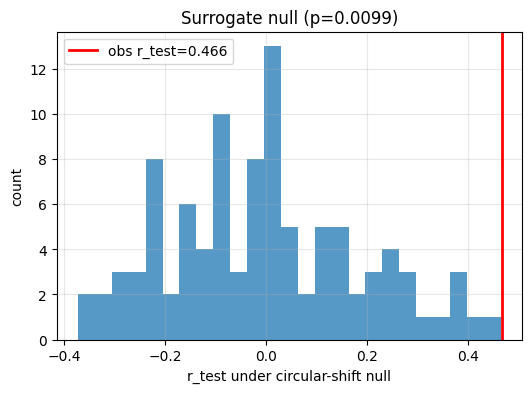

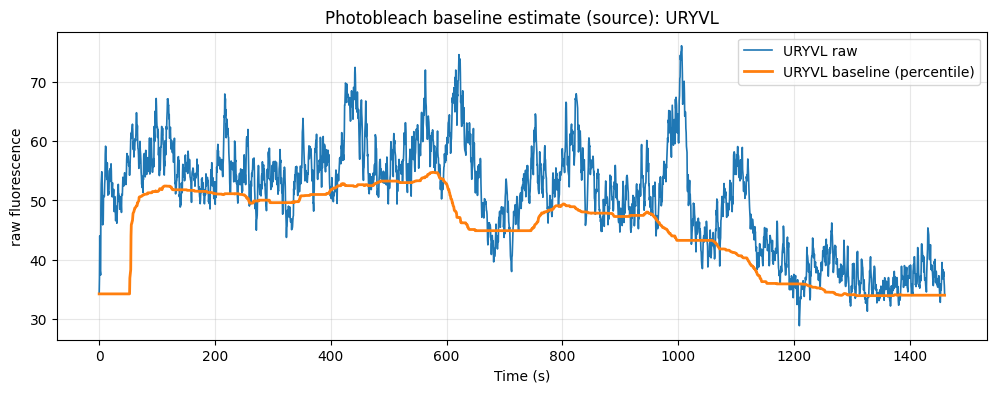

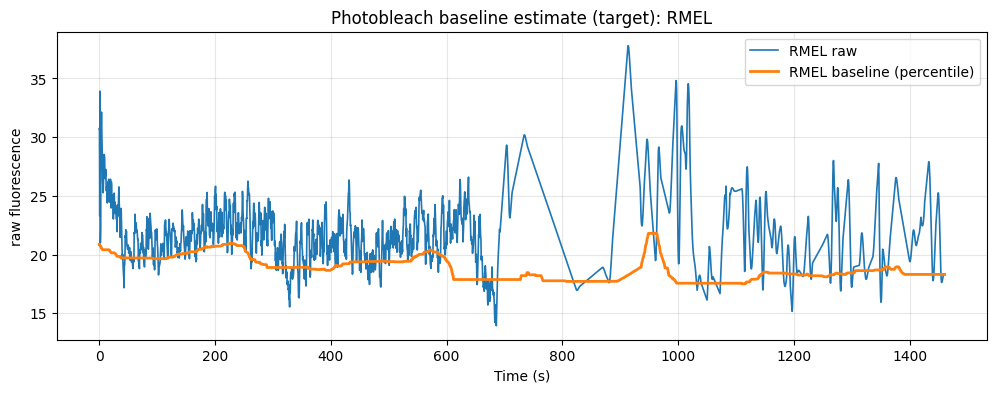

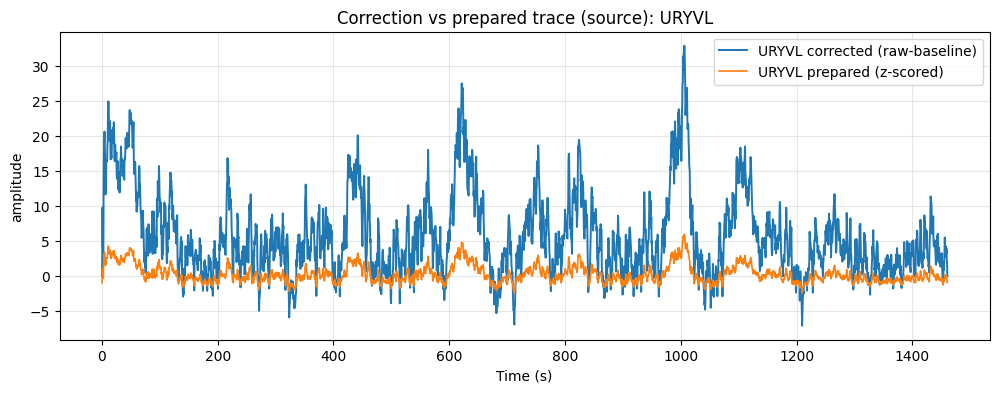

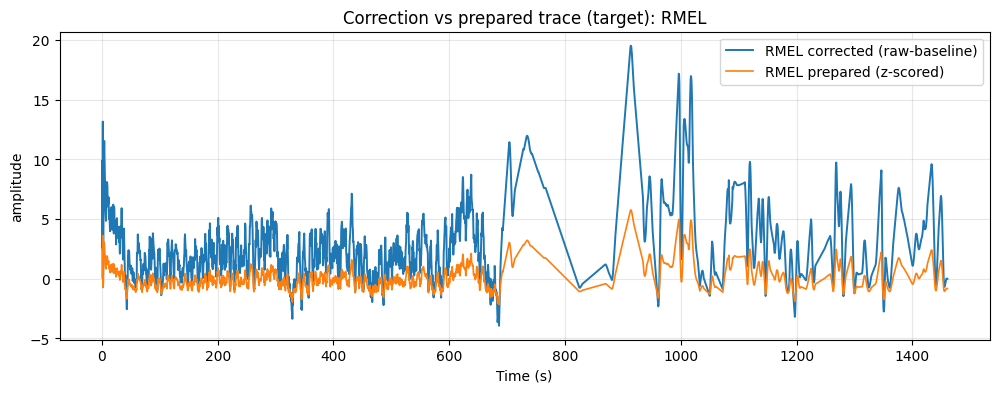

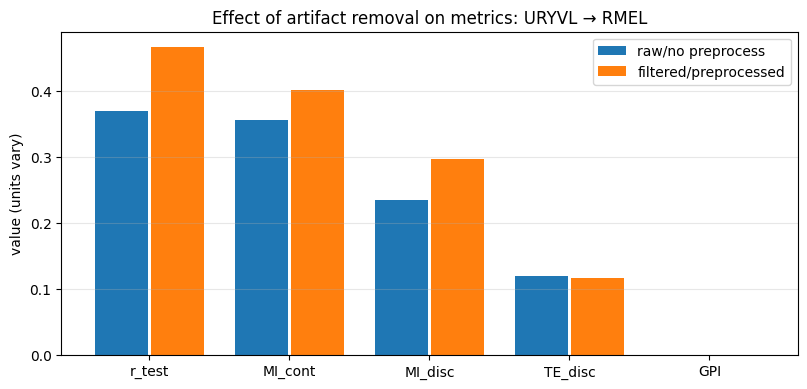

,neuron_id,is_sensory,is_motor,is_interneuron_like
0,AFDL,False,False,True
1,AFDR,False,False,True
2,AIML,False,False,True
3,AIMR,False,False,True
4,AINR,False,False,True
5,AIZL,False,False,True
6,AIZR,False,False,True
7,ASEL,False,False,True
8,ASER,False,False,True
9,ASGL,False,False,True


,source_id,target_id,lag,lag_seconds,r_test,p_r,mi_bits,te_bits_disc,gpi_bits,mi_norm,gpi_norm,q_r,screen_score
0,URYVL,RMEL,0,0.0,0.465809,0.009901,0.400743,0.116352,0.000000,0.120636,0.000000,0.267327,0.309644
1,IL1VR,RMDDR,0,0.0,0.370035,0.009901,0.197733,0.136579,0.000000,0.059523,0.000000,0.267327,0.236902
2,OLQDR,RMEL,0,0.0,0.422834,0.029703,0.337367,0.118176,0.000000,0.101558,0.000000,0.534653,0.279090
3,IL1VL,RMEL,0,0.0,0.401225,0.069307,0.256159,0.109055,0.000000,0.077112,0.000000,0.623762,0.260013
4,OLQDR,RMDL,0,0.0,0.311907,0.118812,0.498985,0.091105,0.000000,0.150209,0.000000,0.623762,0.224697
5,OLQDL,RMEL,0,0.0,0.333342,0.049505,0.263043,0.101152,0.000000,0.079184,0.000000,0.623762,0.219801
6,IL1VR,RMDL,0,0.0,-0.253917,0.138614,0.315181,0.097238,0.000000,0.094879,0.000000,0.623762,0.176070
7,OLQDL,RMDL,0,0.0,0.252705,0.108911,0.292980,0.103528,0.000000,0.088196,0.000000,0.623762,0.173672
8,OLQDL,RMDDL,0,0.0,0.243195,0.099010,0.187511,0.160137,0.000000,0.056446,0.000000,0.623762,0.160029
9,URXL,SMDVR,0,0.0,0.260475,0.069307,0.043102,0.158620,0.000000,0.012975,0.000000,0.623762,0.159529


,source_id,lag,lag_seconds,r_test,p_r,mi_bits,te_bits_disc,gpi_bits,mi_norm,gpi_norm,screen_score,atlas_prior,combined_score
0,URYVL,0,0.0,0.465809,0.009901,0.400743,0.116352,0.000000,0.120636,0.000000,0.309644,0.0,0.309644
1,OLQDR,0,0.0,0.422834,0.029703,0.337367,0.118176,0.000000,0.101558,0.000000,0.279090,0.0,0.279090
2,I2L,0,0.0,0.367179,0.049505,0.560321,0.105956,0.004222,0.168673,0.001271,0.262666,0.0,0.262666
3,IL1VL,0,0.0,0.401225,0.069307,0.256159,0.109055,0.000000,0.077112,0.000000,0.260013,0.0,0.260013
4,AVJL,0,0.0,0.375999,0.009901,0.363739,0.102584,0.000000,0.109496,0.000000,0.252974,0.0,0.252974
5,OLQDL,0,0.0,0.333342,0.049505,0.263043,0.101152,0.000000,0.079184,0.000000,0.219801,0.0,0.219801
6,SAAVR,0,0.0,-0.240390,0.108911,0.885508,0.125914,0.000000,0.266565,0.000000,0.210875,0.0,0.210875
7,DB2,0,0.0,0.280994,0.198020,0.337820,0.106928,0.000000,0.101694,0.000000,0.194020,0.0,0.194020
8,AVAR,0,0.0,-0.272517,0.138614,0.215054,0.114418,0.000000,0.064738,0.000000,0.179694,0.0,0.179694
9,SMDVR,0,0.0,-0.232082,0.099010,0.188616,0.109407,0.000000,0.056779,0.000000,0.153444,0.0,0.153444


,source_id,delta_r2,percent_contribution,base_r2
0,RMEL,1.743299,99.993712,0.970248
1,OLQDL,0.000110,0.006288,0.970248
2,URYVL,0.000000,0.000000,0.970248
3,I2L,0.000000,0.000000,0.970248
4,SAAVR,0.000000,0.000000,0.970248
5,AVJL,0.000000,0.000000,0.970248
6,DB2,0.000000,0.000000,0.970248
7,stim_RIGR,0.000000,0.000000,0.970248
8,stim_unknown,0.000000,0.000000,0.970248
9,URYVR,0.000000,0.000000,0.970248


,source_id,delta_r2,percent_contribution,base_r2
0,RMEL,9.590352e-01,90.646610,0.473038
1,OLQDR,4.817183e-02,4.553131,0.473038
2,AIZR,2.423414e-02,2.290575,0.473038
3,DB2,2.119025e-02,2.002871,0.473038
4,stim_other,2.798166e-03,0.264479,0.473038
5,URYVL,2.563877e-03,0.242334,0.473038
6,stim_SAAVL,0.000000e+00,0.000000,0.473038
7,stim_RMDL,0.000000e+00,0.000000,0.473038
8,stim_CEPDR,0.000000e+00,0.000000,0.473038
9,stim_FLPL,0.000000e+00,0.000000,0.473038


motor_target: RMEL
R² linear: 0.9702482881102474
R² neural: 0.4730380985579602
top_contributor_pair_metrics present: False


In [73]:

from celegans_unified_pipeline.workflow import run_single_dataset
from celegans_unified_pipeline.atlas import load_atlas_table

SELECTION_MODE = "nested"   # 'nested' (rigorous) or 'simple' (fast)

# Contributor toggles
INCLUDE_SENSORY = True
INCLUDE_MOTOR = True
INCLUDE_INTERNEURONS = True
INCLUDE_OTHER = True

# Target-history toggle
INCLUDE_TARGET_HISTORY = True

TOP_PAIR_K = 20
TOP_CONTRIBUTOR_K = 12

atlas_df = load_atlas_table(atlas_path) if atlas_path is not None else None

res = run_single_dataset(
    dataset=dataset,
    neuron_classes=neuron_classes,
    atlas_df=atlas_df,
    motor_target=None,
    include_sensory=INCLUDE_SENSORY,
    include_motor=INCLUDE_MOTOR,
    include_interneurons=INCLUDE_INTERNEURONS,
    include_other=INCLUDE_OTHER,
    include_target_history=INCLUDE_TARGET_HISTORY,
    top_pair_k=TOP_PAIR_K,
    top_contributor_k=TOP_CONTRIBUTOR_K,
    selection_mode=SELECTION_MODE,
)

display(res["role_table"].head(25))
display(res["screen_table"].head(25))
display(res["contributor_table"].head(25))
display(res["predictor_fit"]["linear_contributor_table"].head(25))  # linear-model contributor table
display(res["predictor_fit"]["neural_contributor_table"].head(25))  # neural-model contributor table
print("motor_target:", res["motor_target"])
print("R² linear:", res["predictor_fit"]["linear_r2_test"])
print("R² neural:", res["predictor_fit"]["neural_r2_test"])


print('top_contributor_pair_metrics present:', res.get('top_contributor_pair_metrics') is not None)


## 3b) Analyze a specific pair (user-chosen) and/or run worst-pair deep-dive
Use these options when you want to test an explicitly chosen sensory/motor pair, or to inspect a low-dependence control pair via `pair_selection='worst'`.

In [74]:
from celegans_unified_pipeline.workflow import run_pair_of_choice

# Example: deep-dive a specific pair of choice (edit IDs to your neurons)
RUN_CUSTOM_PAIR = False
CUSTOM_SOURCE = "OLQVR"
CUSTOM_TARGET = res["motor_target"]  # or a specific motor neuron name

if RUN_CUSTOM_PAIR:
    custom_metrics = run_pair_of_choice(
        dataset=dataset,
        neuron_classes=neuron_classes,
        atlas_df=atlas_df,
        source_id=CUSTOM_SOURCE,
        target_id=CUSTOM_TARGET,
        selection_mode=SELECTION_MODE,
        save_dir=None,
        show_filter_diagnostics=True,
    )

# Example: run the pipeline but deep-dive the WORST screened sensory→motor pair instead of the best
RUN_WORST_PAIR = False
if RUN_WORST_PAIR:
    res_worst = run_single_dataset(
        dataset=dataset,
        neuron_classes=neuron_classes,
        atlas_df=atlas_df,
        motor_target=None,
        include_sensory=INCLUDE_SENSORY,
        include_motor=INCLUDE_MOTOR,
        include_interneurons=INCLUDE_INTERNEURONS,
        include_other=INCLUDE_OTHER,
        include_target_history=INCLUDE_TARGET_HISTORY,
        top_pair_k=TOP_PAIR_K,
        top_contributor_k=TOP_CONTRIBUTOR_K,
        selection_mode=SELECTION_MODE,
        pair_selection="worst",  # <--- toggle
    )

## 4) Toggle/ablation suite (quantify the value of interneurons and target history)

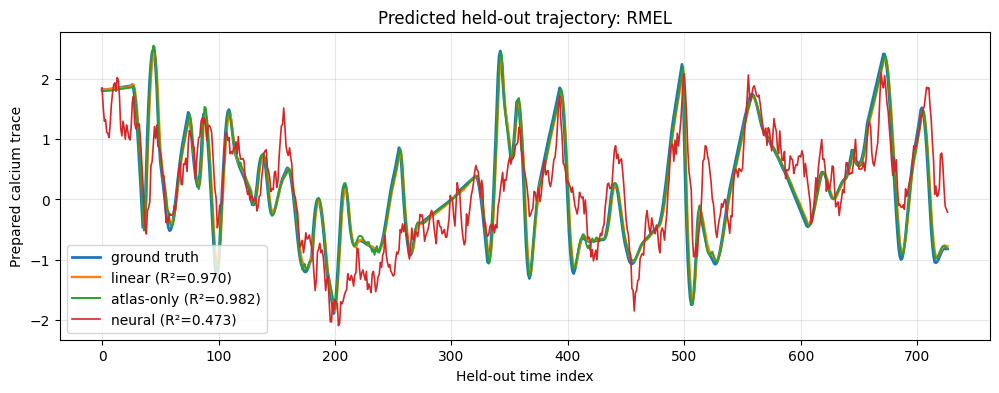

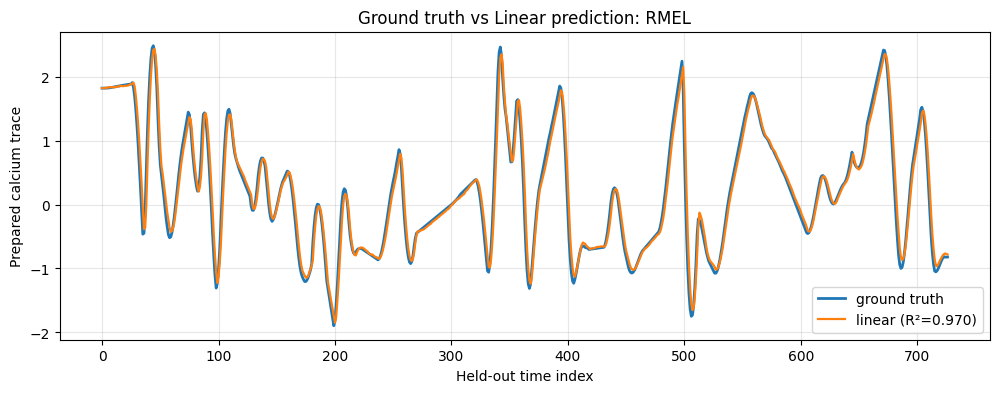

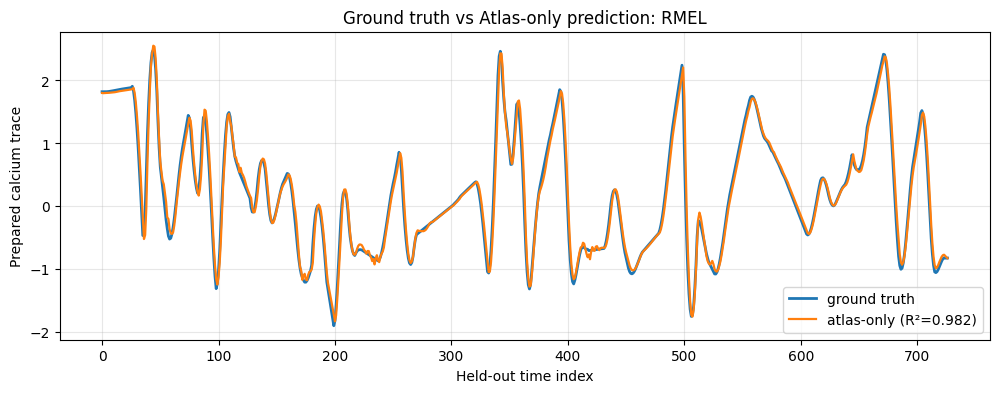

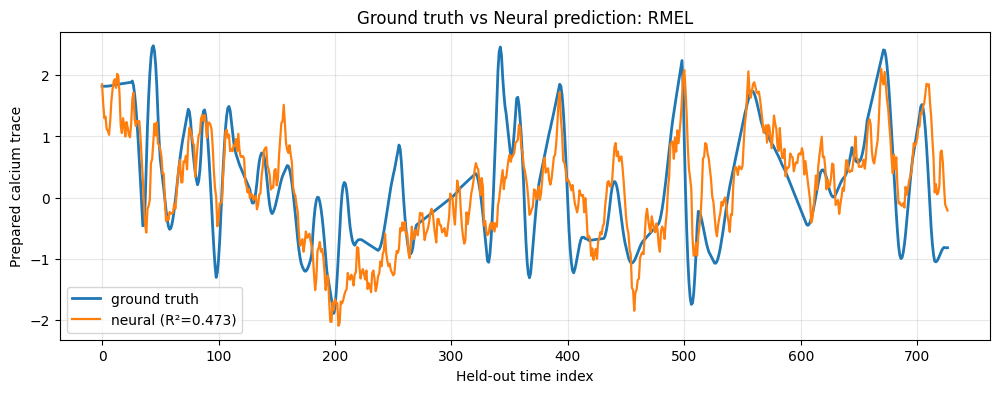

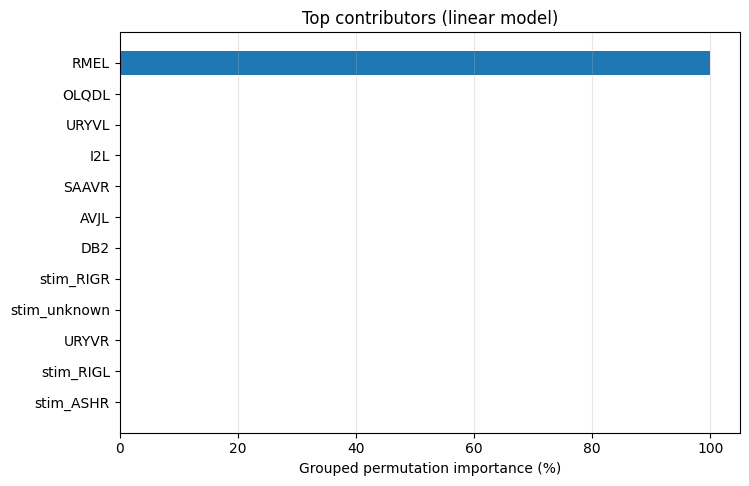

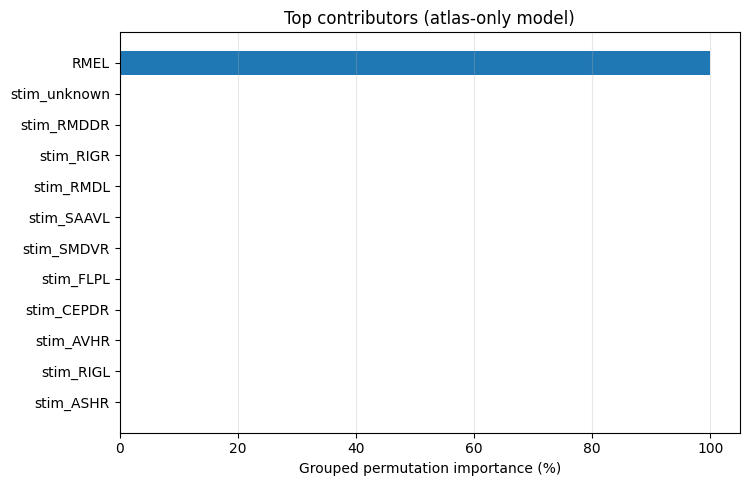

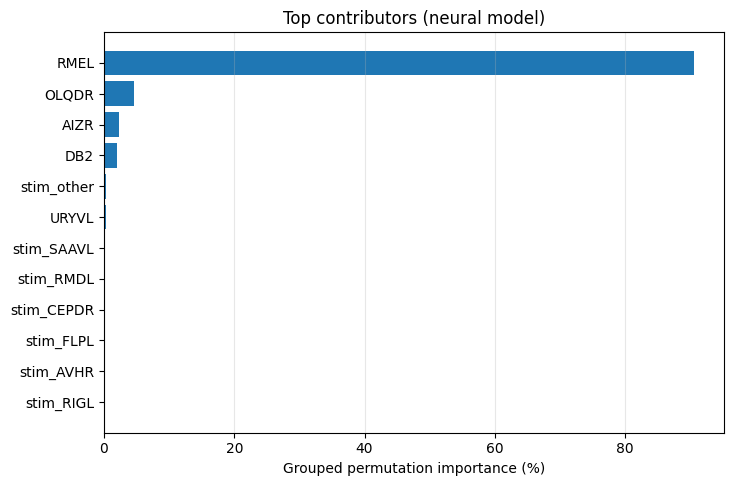

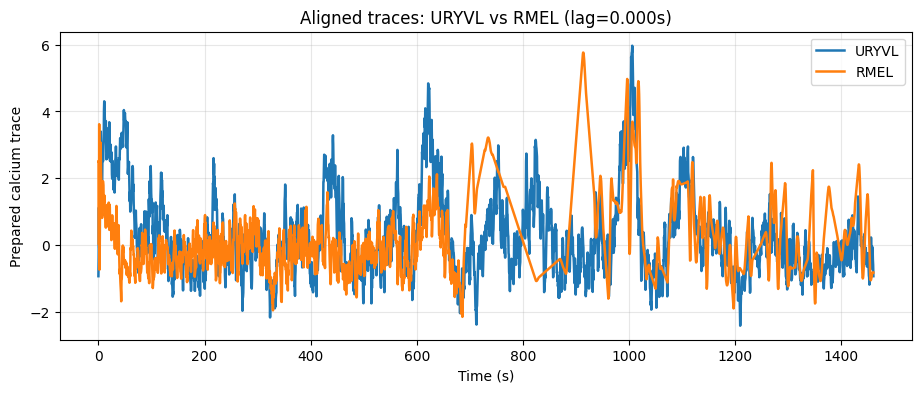

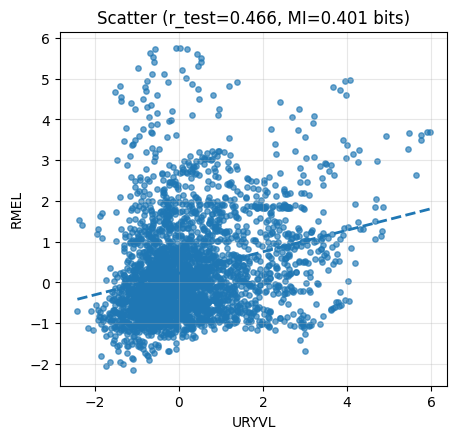

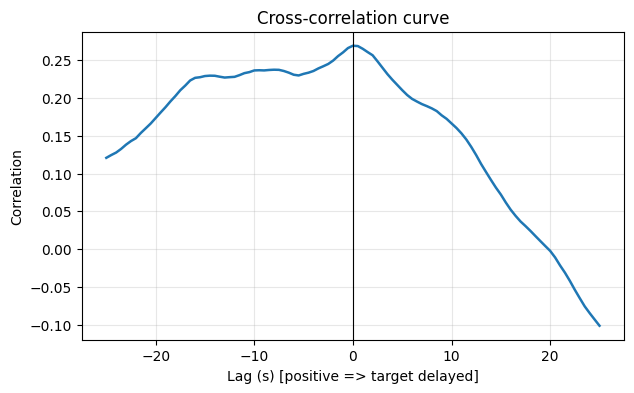

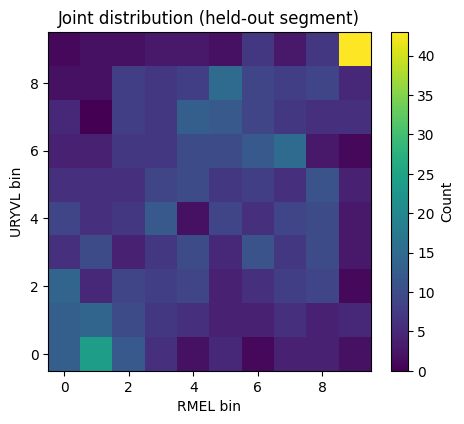

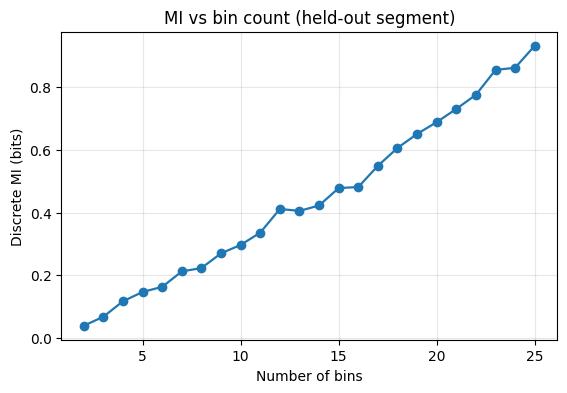

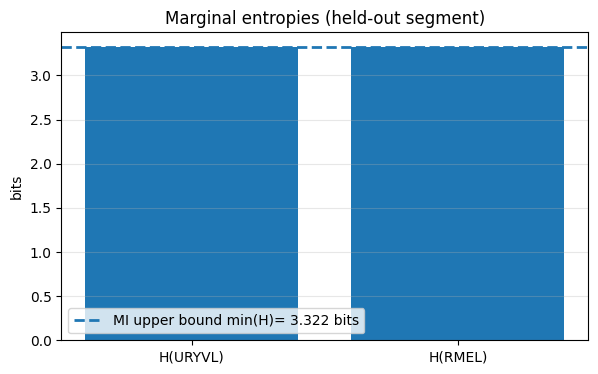

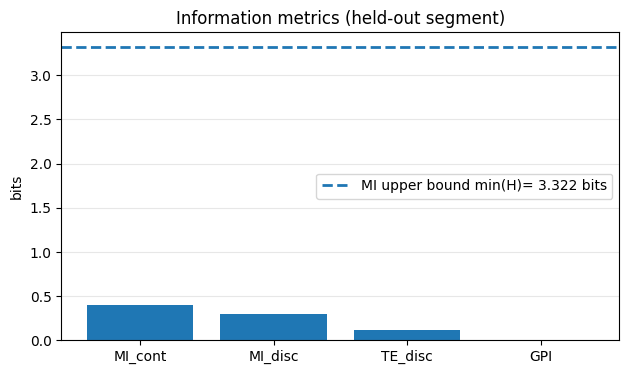

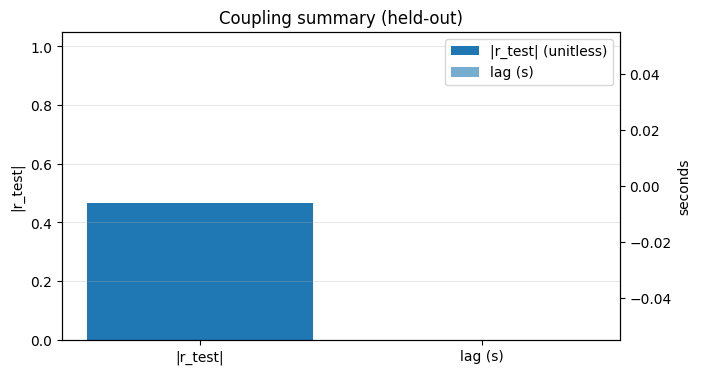

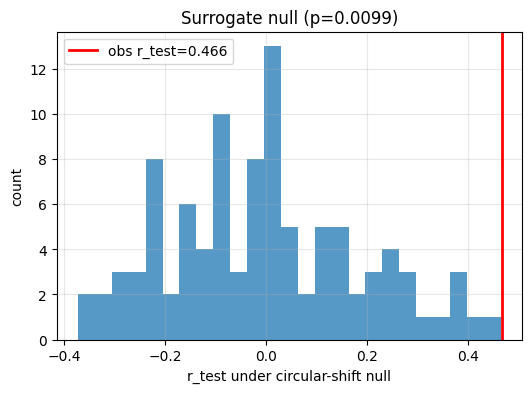

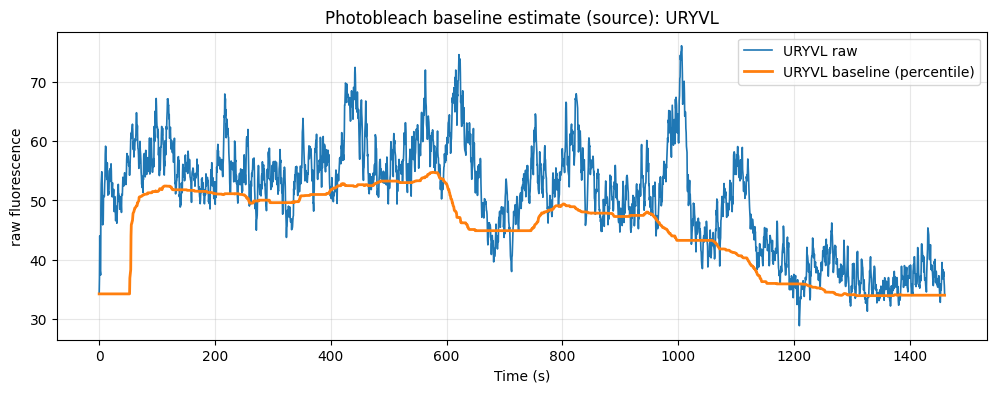

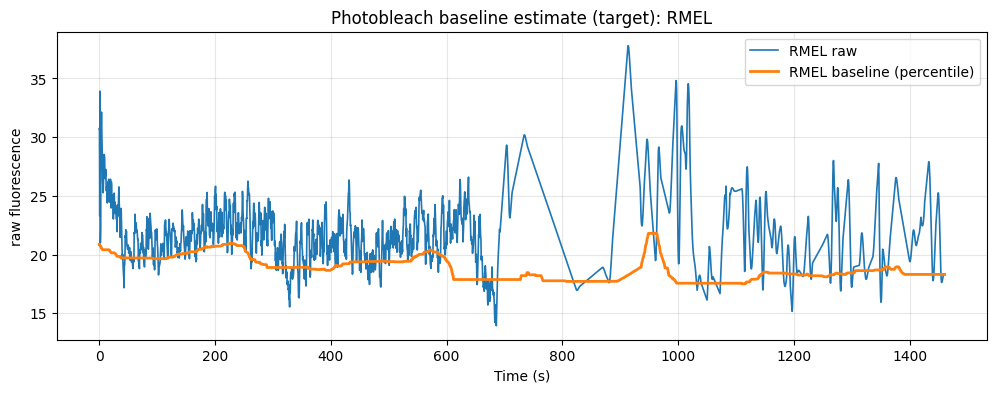

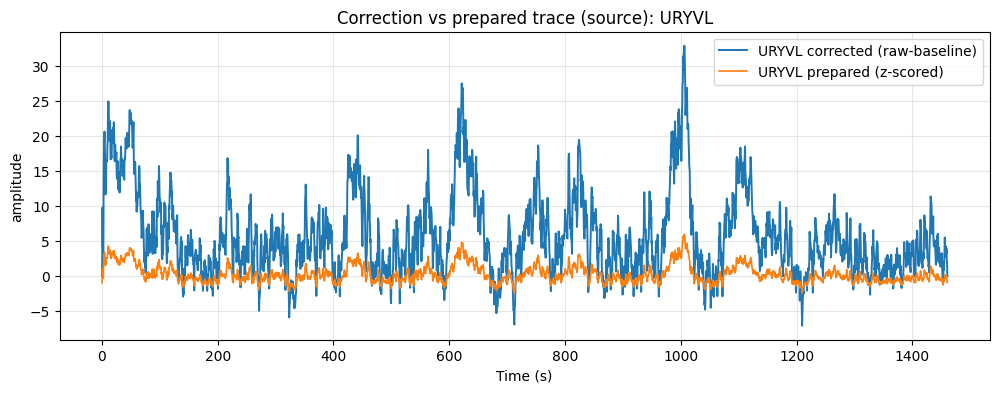

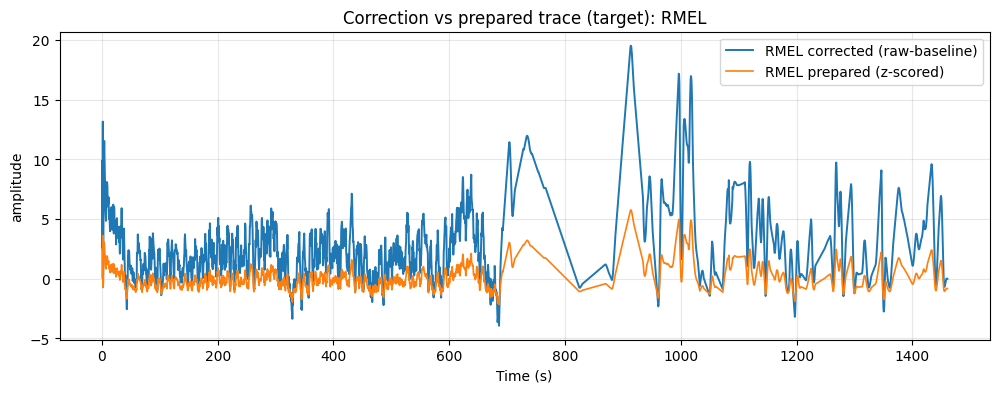

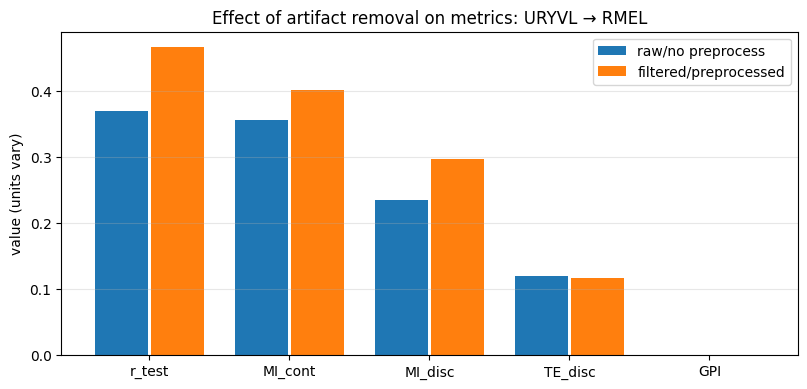

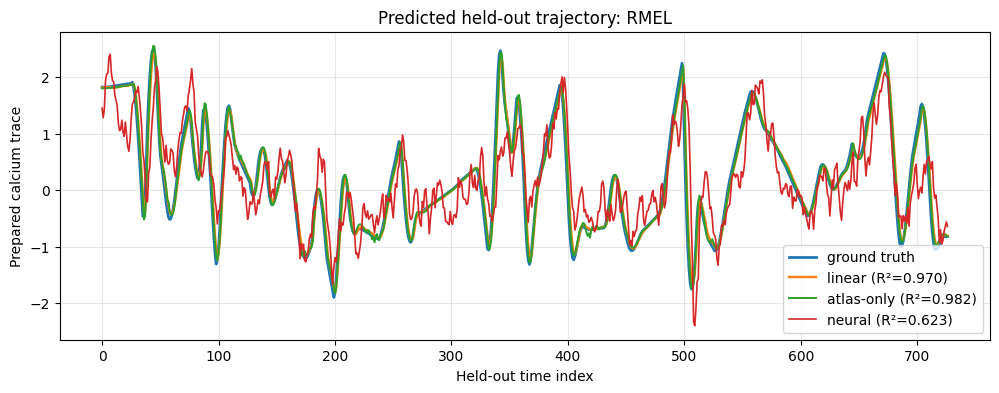

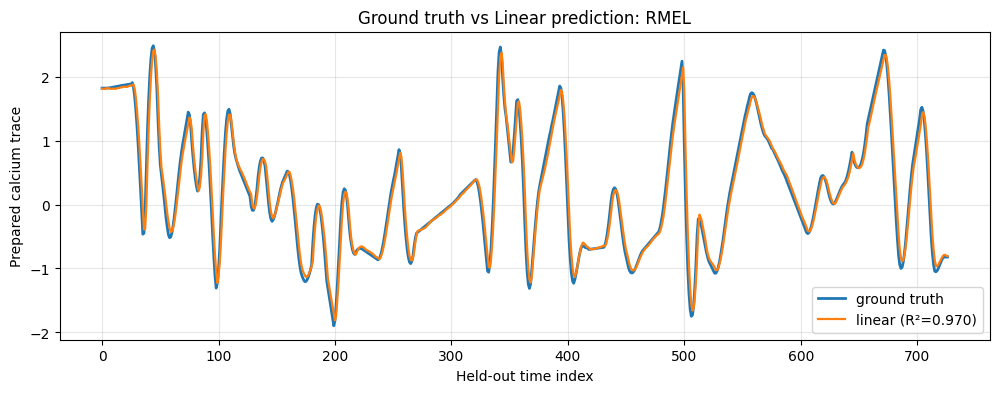

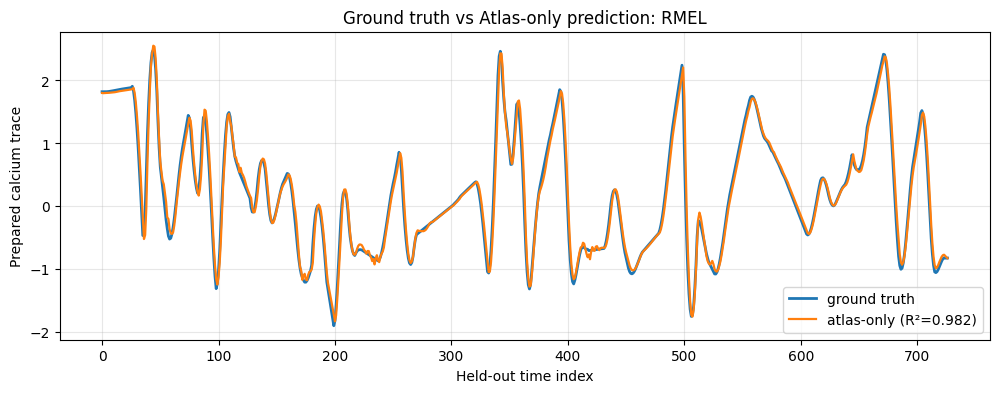

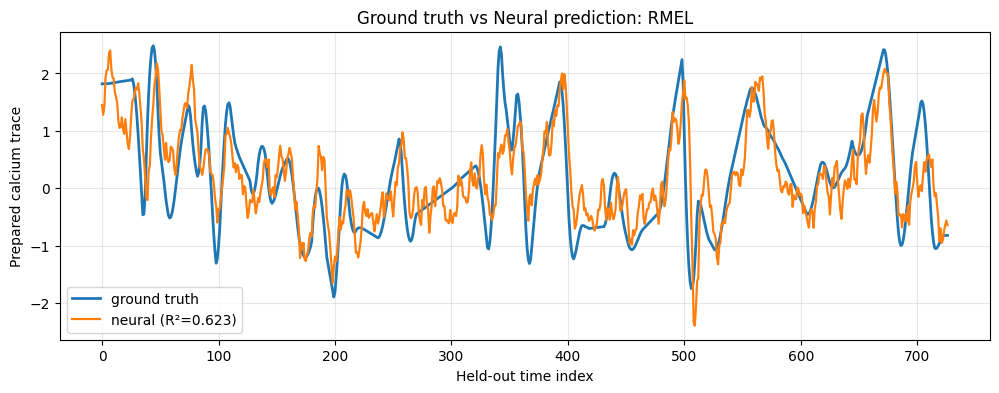

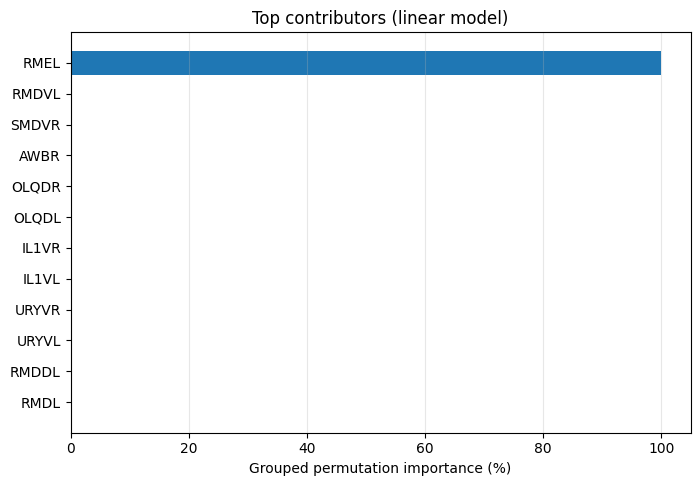

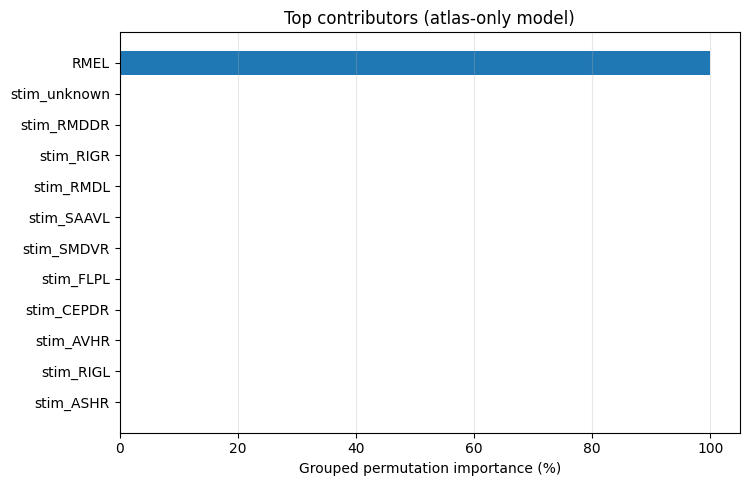

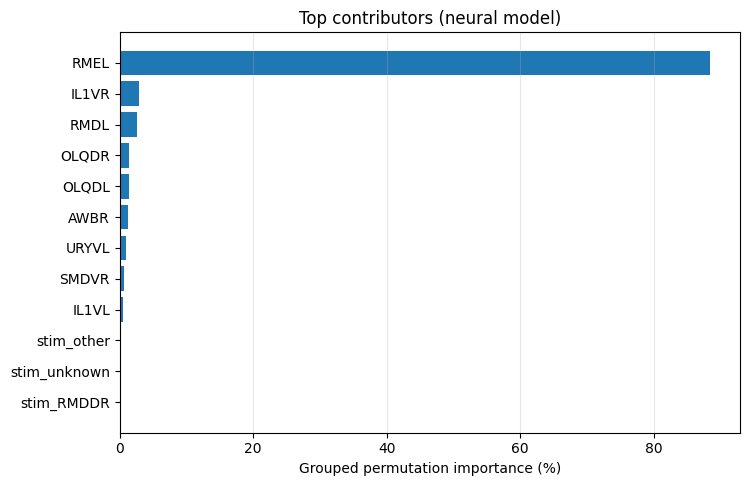

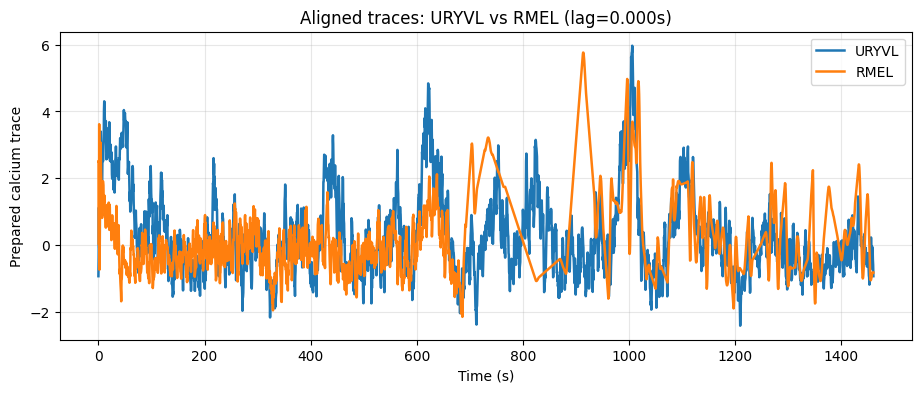

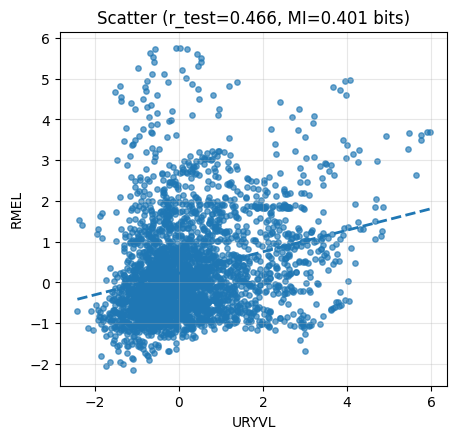

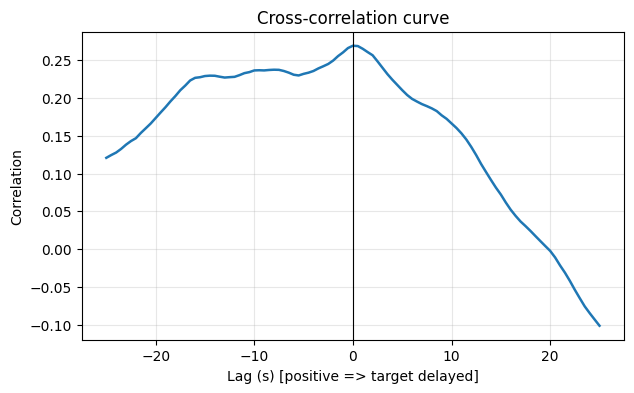

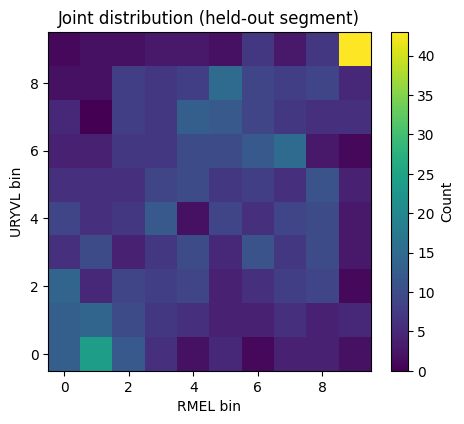

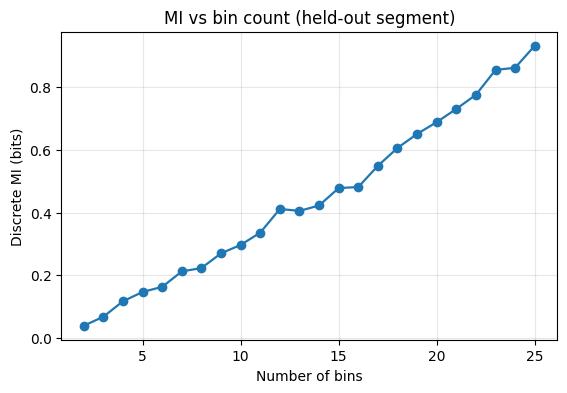

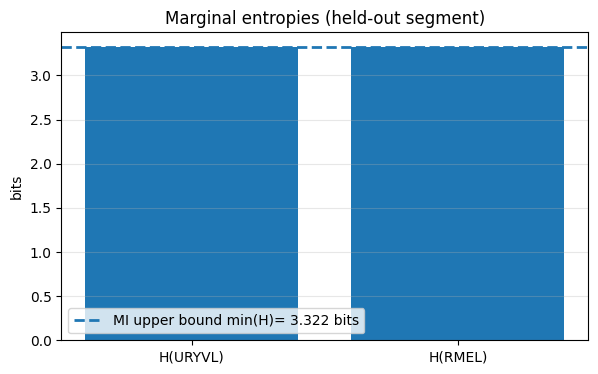

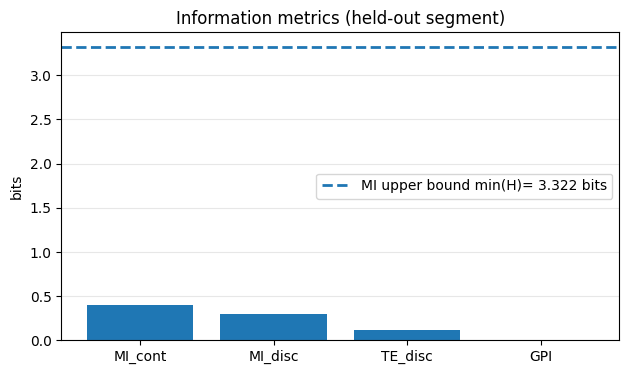

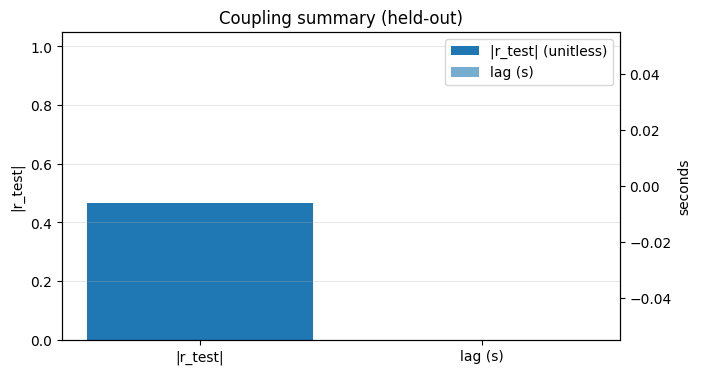

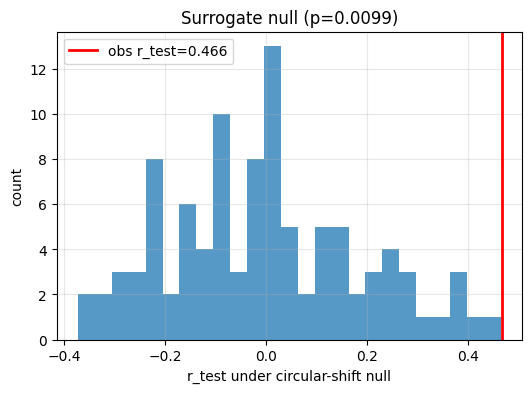

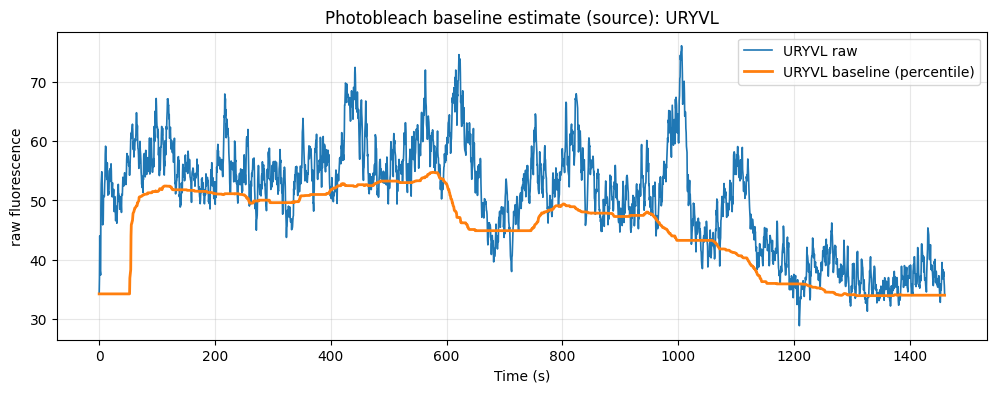

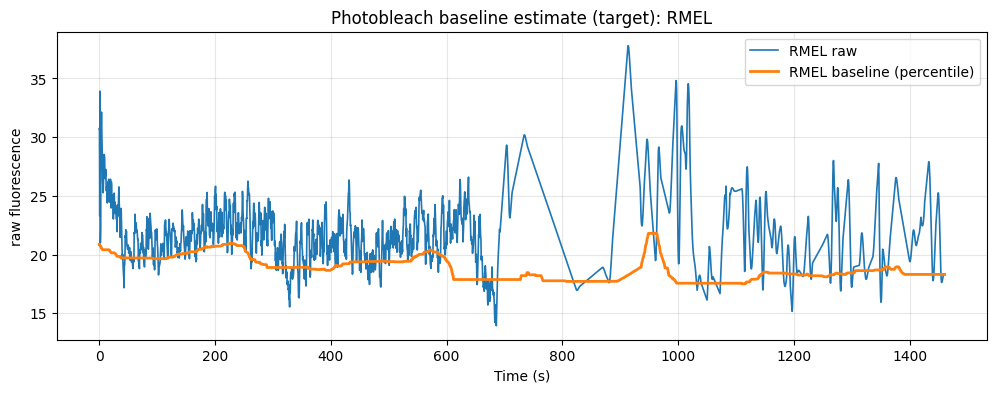

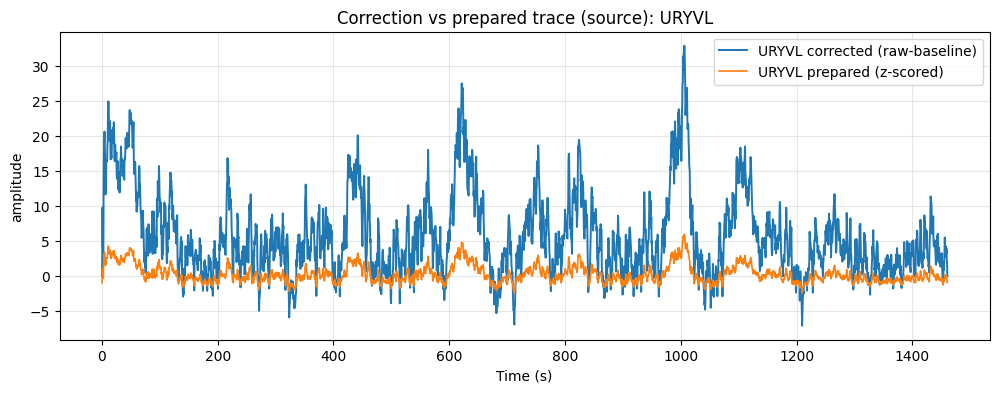

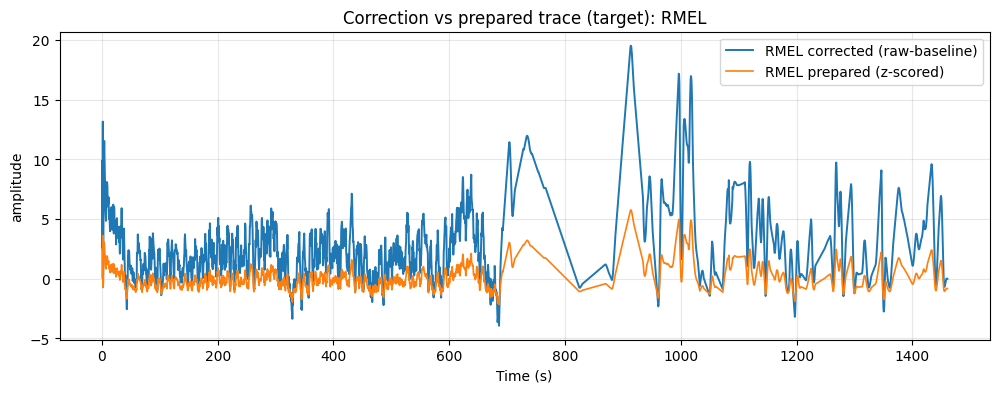

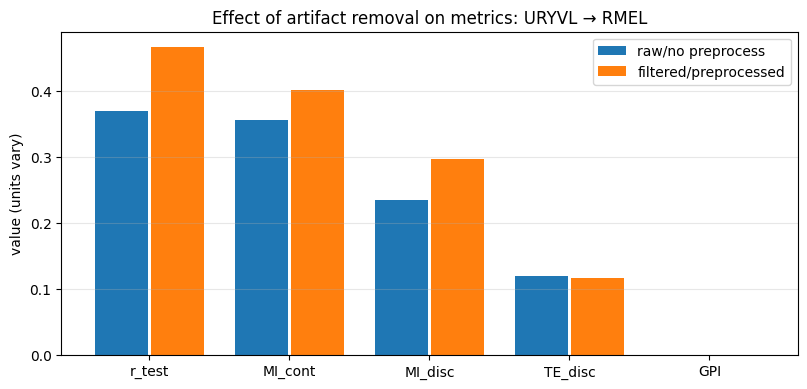

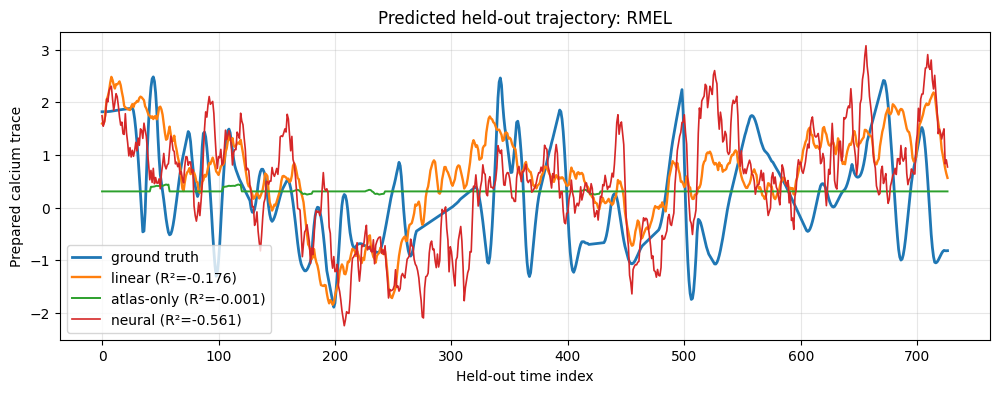

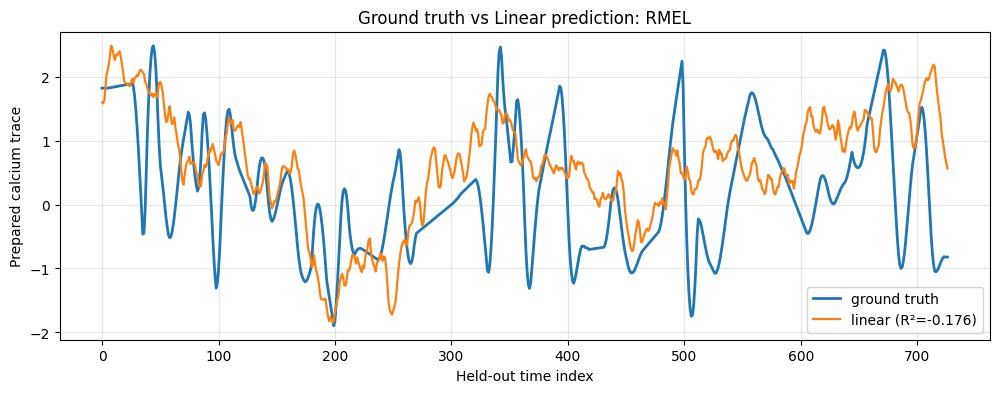

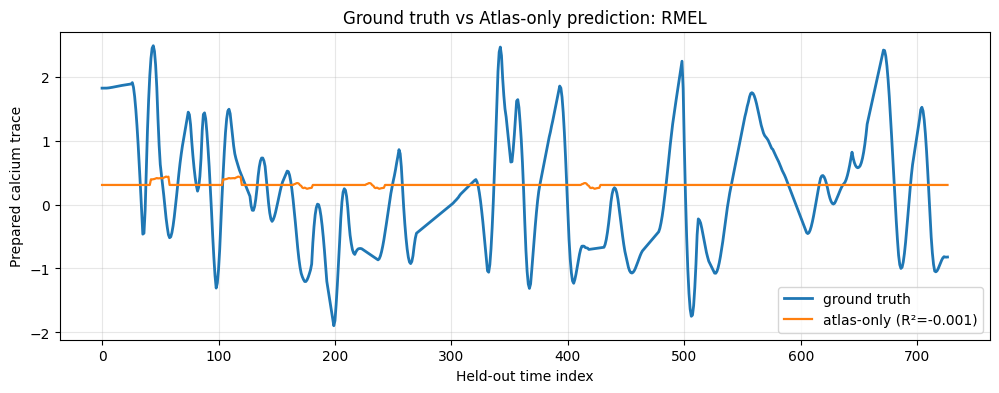

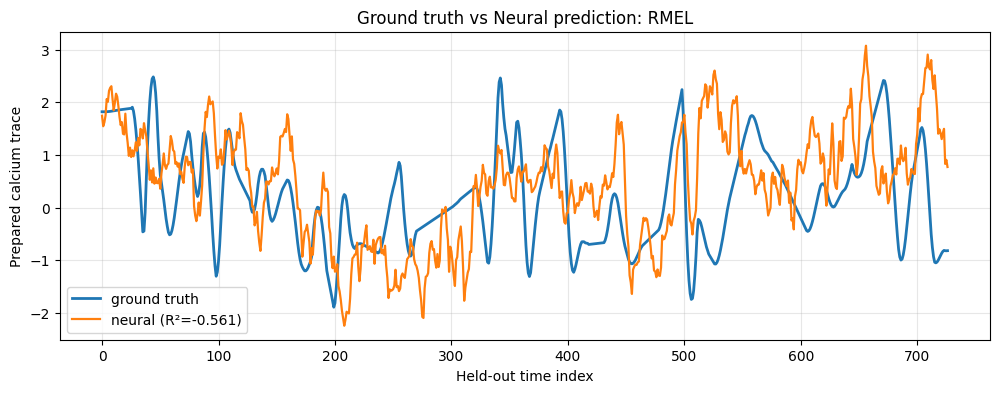

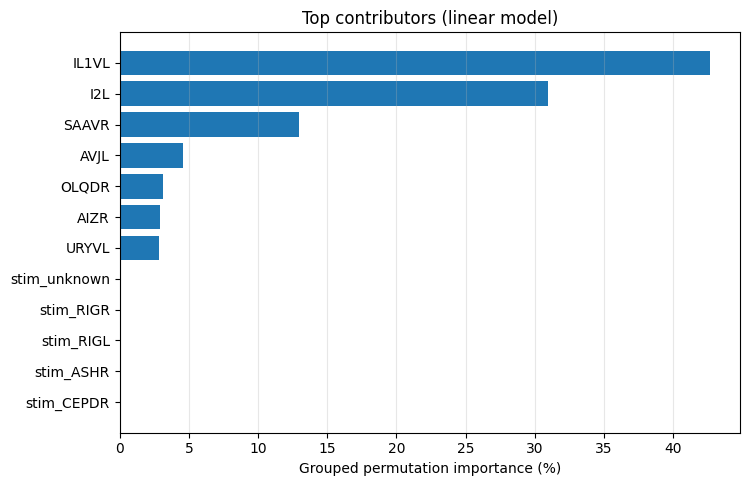

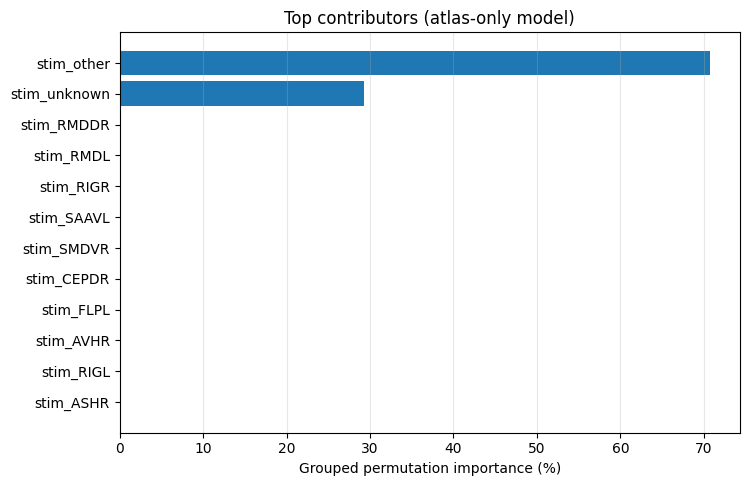

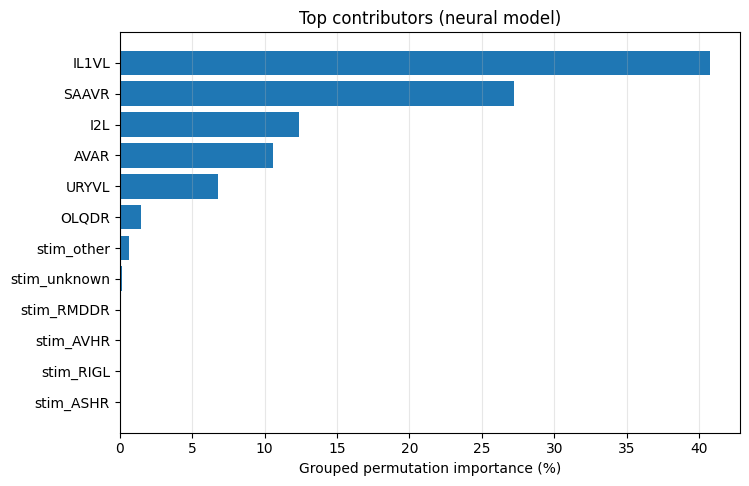

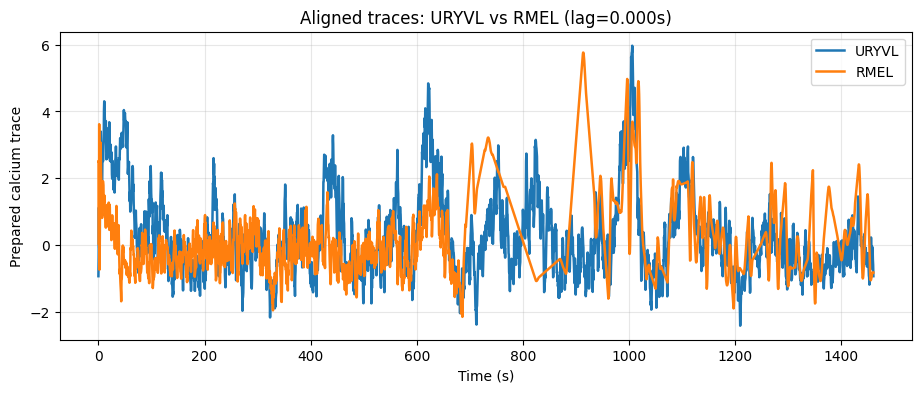

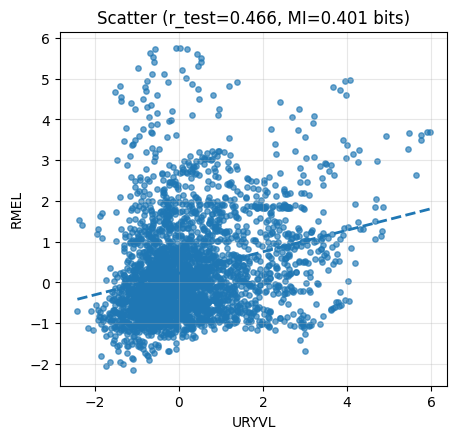

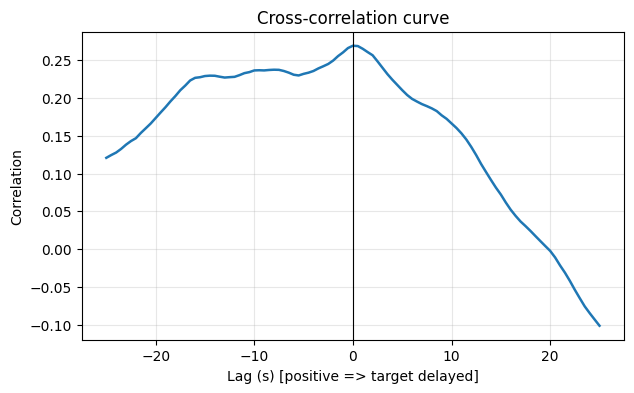

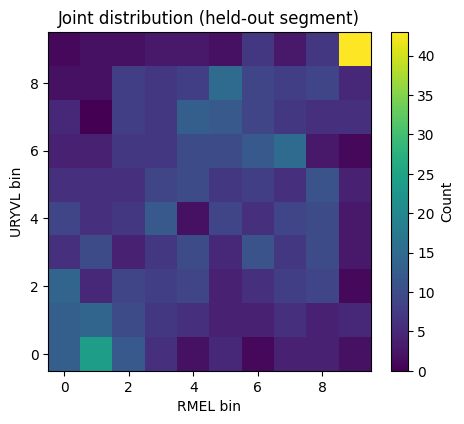

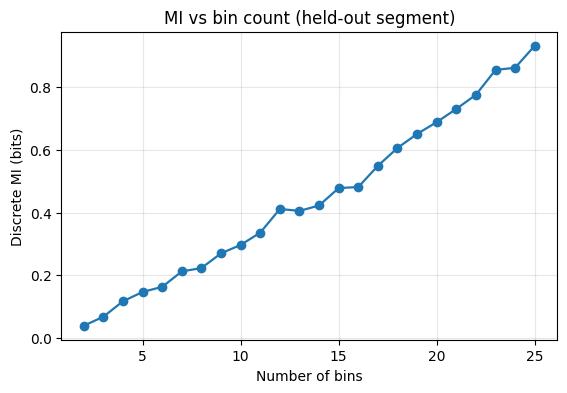

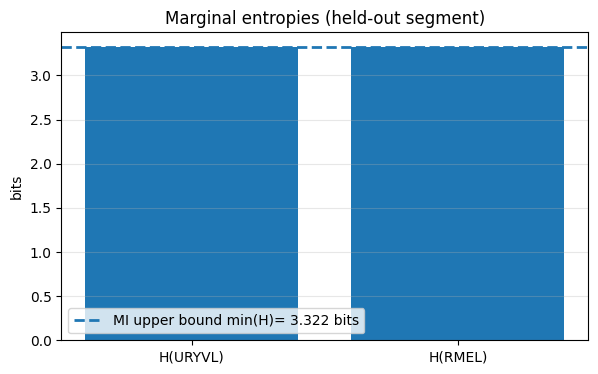

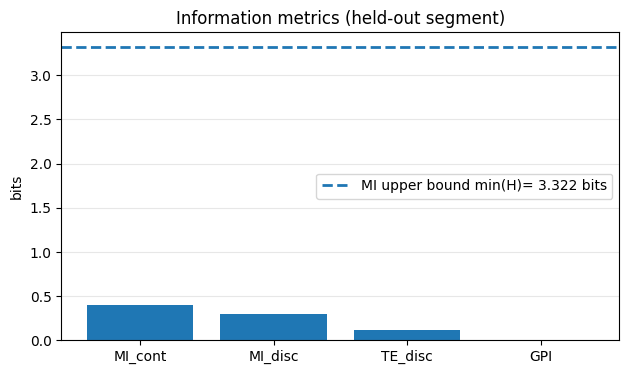

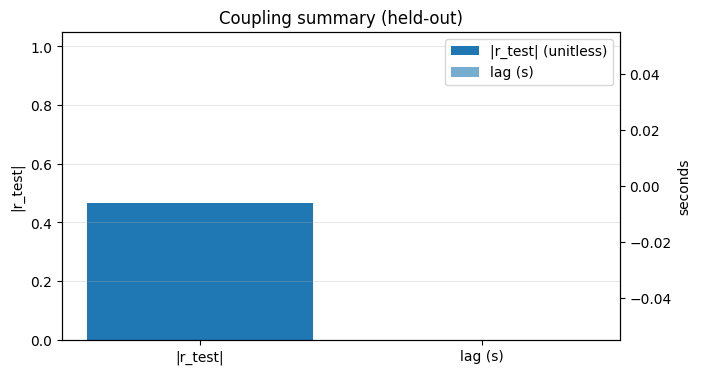

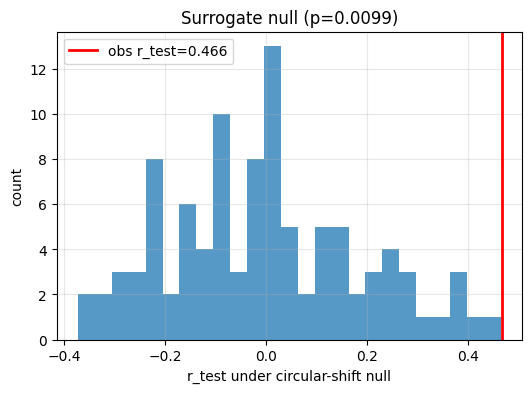

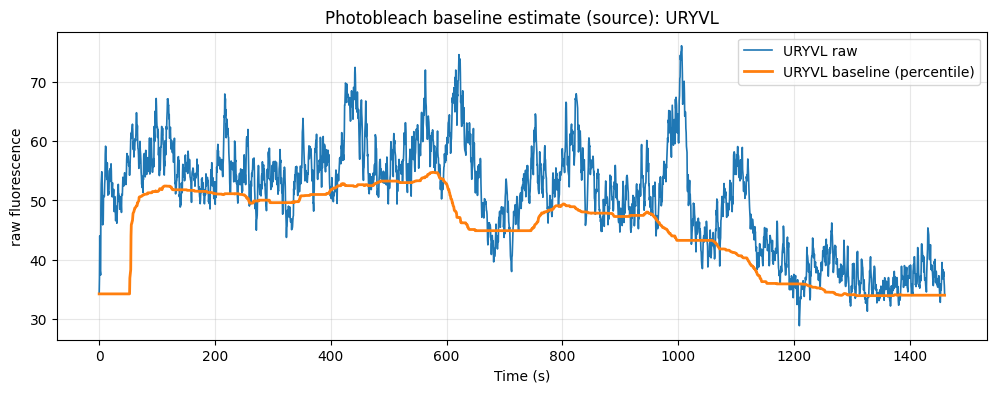

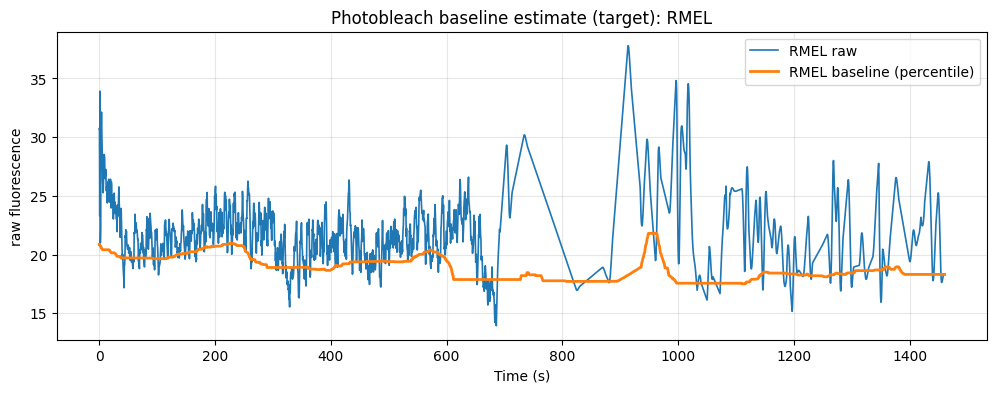

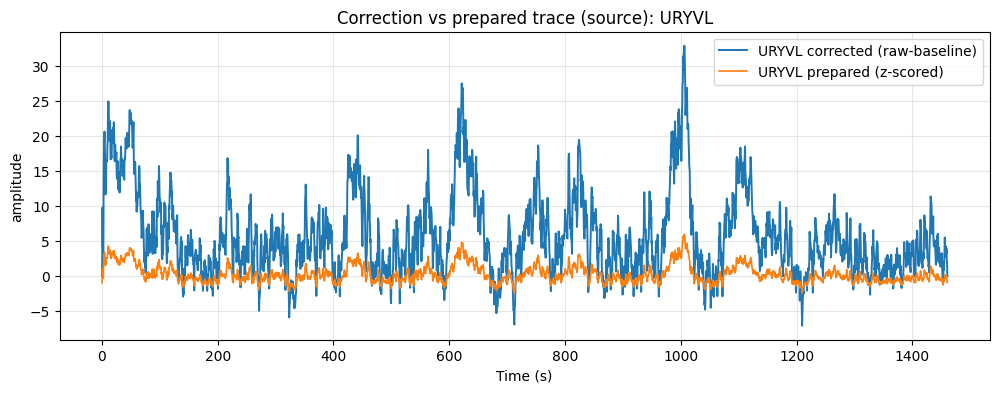

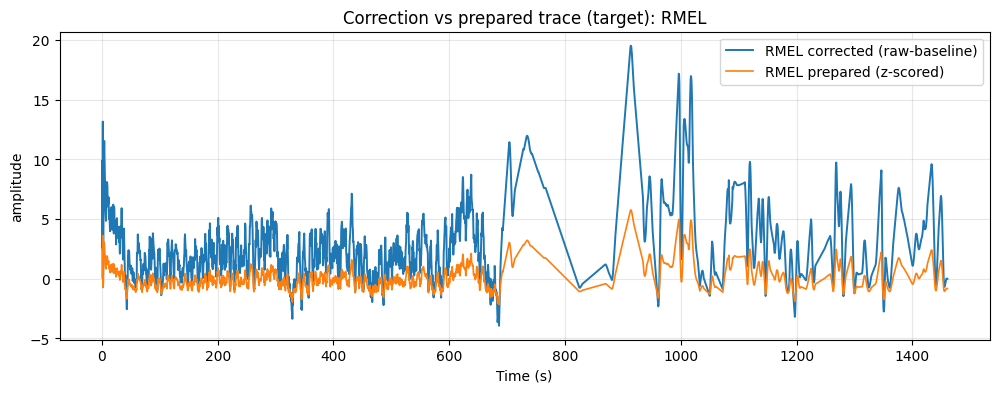

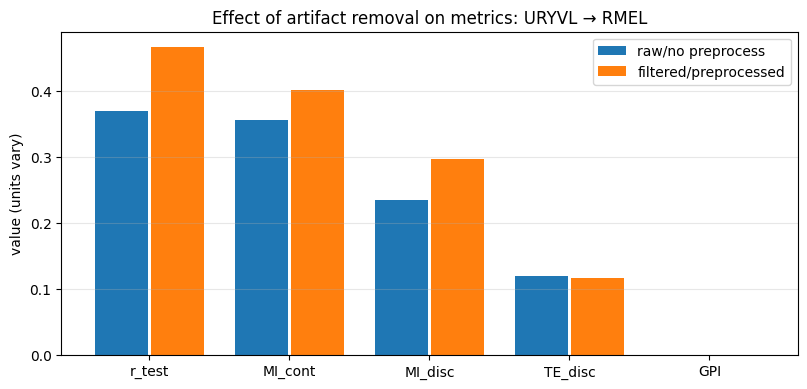

,name,motor_target,include_target_history,include_interneurons,linear_R2,neural_R2,atlas_only_R2
0,all_on,RMEL,True,True,0.970248,0.473038,0.982187
1,no_interneurons,RMEL,True,False,0.970013,0.622869,0.982187
2,network_only_no_AR,RMEL,False,True,-0.175844,-0.560653,-0.001220


In [75]:

from celegans_unified_pipeline.workflow import run_toggle_suite
abl = run_toggle_suite(dataset, neuron_classes, atlas_df=atlas_df, motor_target=res["motor_target"], selection_mode=SELECTION_MODE,
                       top_pair_k=TOP_PAIR_K, top_contributor_k=TOP_CONTRIBUTOR_K)
display(abl)


## 5) Multi-dataset training (0..112) → evaluate on hold-out dataset

available ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... [103, 104, 105, 106, 107, 108, 109, 110, 111, 112]
[multi] switched reference dataset to 1 because it contains target RMEL
[multi] train_ids with target RMEL: 94/112
[multi] top_sources (n=12): ['ASHL', 'ASHR', 'MI', 'URADL', 'IL1DL', 'I2L', 'IL2L', 'URYDL', 'ASKR', 'RMDDR']


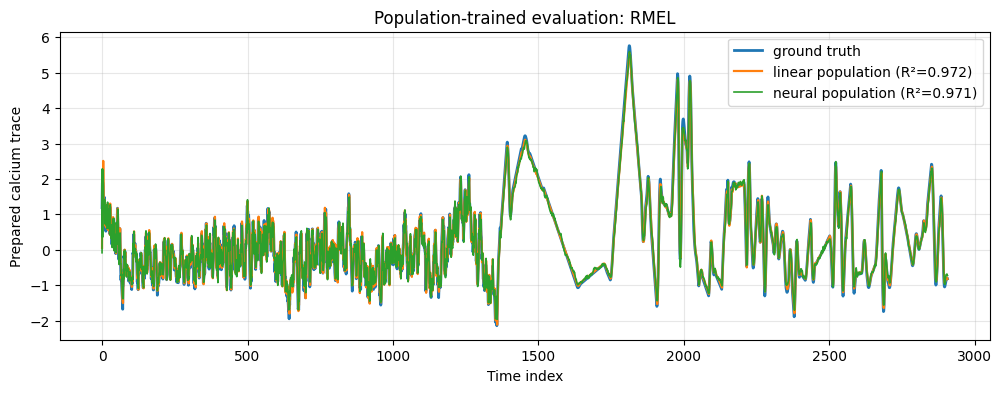

[multi] Evaluation R²: linear=0.972, neural=0.971


,source_id,lag,lag_seconds,r_test,p_r,mi_bits,te_bits_disc,gpi_bits,mi_norm,gpi_norm,screen_score,atlas_prior,combined_score
0,ASHL,0,0.0,-0.151557,0.217822,0.066929,0.086027,0.002102,0.020148,0.000633,0.096066,0.0,0.096066
1,ASHR,0,0.0,-0.147174,0.178218,0.099909,0.091347,0.000434,0.030076,0.000131,0.095843,0.0,0.095843
2,MI,0,0.0,0.133162,0.118812,0.114271,0.090297,0.000000,0.034399,0.000000,0.088497,0.0,0.088497
3,URADL,0,0.0,-0.126350,0.168317,0.054154,0.085004,0.000000,0.016302,0.000000,0.079885,0.0,0.079885
4,IL1DL,0,0.0,-0.124587,0.287129,0.032462,0.085461,0.000000,0.009772,0.000000,0.077195,0.0,0.077195
5,I2L,0,0.0,-0.083530,0.405941,0.173174,0.086220,0.000513,0.052131,0.000155,0.063174,0.0,0.063174
6,IL2L,0,0.0,-0.097423,0.158416,0.021029,0.081512,0.000000,0.006330,0.000000,0.060036,0.0,0.060036
7,URYDL,0,0.0,0.082948,0.524752,0.130019,0.094574,0.000592,0.039140,0.000178,0.059581,0.0,0.059581
8,ASKR,0,0.0,-0.088207,0.386139,0.061396,0.091986,0.000685,0.018482,0.000206,0.057575,0.0,0.057575
9,RMDDR,0,0.0,0.093063,0.217822,0.008147,0.084431,0.001593,0.002452,0.000479,0.056523,0.0,0.056523


Population R² linear: 0.9716099037806034
Population R² neural: 0.9710325794404042
Reference dataset used: 1
Training datasets used: 94


In [76]:
from celegans_unified_pipeline.workflow import run_multi_dataset
from celegans_unified_pipeline.discover import choose_best_exported_dir
from celegans_unified_pipeline.loaders import list_exported_ids

RUN_MULTI = True  # set True to run population training + held-out evaluation

if RUN_MULTI:
    export_dir = choose_best_exported_dir(discovery)
    all_ids = list_exported_ids(export_dir)
    print("available ids:", all_ids[:10], "...", all_ids[-10:])
    TEST_ID = EXPORTED_EXP_ID
    TRAIN_IDS = [i for i in all_ids if i != TEST_ID]

    # Note: target_id from the single-dataset run may not exist in the chosen reference dataset.
    # run_multi_dataset now automatically selects a reference dataset that contains target_id
    # and filters train_ids to those containing the target.
    multi = run_multi_dataset(
        export_dir, neuron_classes, TRAIN_IDS, TEST_ID,
        atlas_df=atlas_df,
        target_id=res["motor_target"],
        include_sensory=True, include_motor=True, include_interneurons=True, include_other=True,
        include_target_history=True,
        top_contributor_k=TOP_CONTRIBUTOR_K,
        selection_mode=SELECTION_MODE,
        verbose=True,
    )

    display(multi["contributor_table_ref"].head(25))
    print("Population R² linear:", multi["evaluation"]["linear_r2"])
    print("Population R² neural:", multi["evaluation"]["neural_r2"])
    print("Reference dataset used:", multi["ref_id"])
    print("Training datasets used:", len(multi["train_ids_used"]))